# 04 - Modelling: Walmart Weekly Sales Forecasting

In this notebook we build and evaluate forecasting models for weekly sales.

**Why we are doing this:**
- The business needs better demand forecasts to reduce stockouts and overstock.
- A model that outperforms a simple baseline (e.g. last week's sales) can support
  more reliable planning decisions.
- We will compare a naive baseline against a tree based model and quantify the
  improvement using appropriate error metrics.


## Load feature engineered data and import modelling libraries

**Why:**
We use the feature engineered dataset from Notebook 3 (`df_model_ready`) because:
- It already contains lag features and rolling statistics.
- Early rows without enough history have been removed.
- It is ready to be used directly in a supervised learning setup.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define paths
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Path to model-ready dataset created in Notebook 3
model_ready_path = DATA_PROCESSED / "walmart_features_model_ready.csv"

# Load dataset, ensuring 'date' is parsed as datetime
df = pd.read_csv(model_ready_path, parse_dates=["date"])

print("Data loaded from:", model_ready_path)
print("Shape:", df.shape)
df.head()


Data loaded from: C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\walmart_features_model_ready.csv
Shape: (6255, 19)


,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,year,month,weekofyear,dayofweek,is_month_start,is_month_end,weekly_sales_lag_1,weekly_sales_lag_2,weekly_sales_lag_4,rolling_mean_4,rolling_std_4
0,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,4,0,0,1409727.59,1611968.17,1643690.90,1.554615e+06,103135.002548
1,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,4,0,0,1554806.68,1409727.59,1641957.44,1.504011e+06,95360.050839
2,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,4,0,0,1439541.59,1554806.68,1611968.17,1.469148e+06,62599.457150
3,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,4,0,0,1472515.79,1439541.59,1409727.59,1.467823e+06,64308.381016
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,4,0,0,1404429.92,1472515.79,1554806.68,1.477864e+06,82871.762296


## Define target variable and feature set

**Why:**
Machine learning models need:
- A **target variable** we want to predict: here `weekly_sales`.
- A set of **input features** that the model will use to make predictions.

We exclude:
- The target (`weekly_sales`) itself from features.
- Any identifiers like `date` and `store` which can be used for grouping and
  evaluation, but not directly as numeric features here (we already encoded
  time via calendar features and lags).


In [2]:
# Define target variable
target_col = "weekly_sales"

# List of columns to exclude from features
exclude_cols = [
    "weekly_sales",  # target
    "date",          # identifier/time index
    "store",         # store id (we could one-hot encode later if needed)
]

# Build feature list by excluding unwanted columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print("Target column:", target_col)
print("Number of feature columns:", len(feature_cols))
print("Feature columns:", feature_cols)

# Create X (features) and y (target)
X = df[feature_cols].copy()
y = df[target_col].copy()


Target column: weekly_sales
Number of feature columns: 16
Feature columns: ['holiday_flag', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'year', 'month', 'weekofyear', 'dayofweek', 'is_month_start', 'is_month_end', 'weekly_sales_lag_1', 'weekly_sales_lag_2', 'weekly_sales_lag_4', 'rolling_mean_4', 'rolling_std_4']


## Create a time based train/test split

**Why not random split?**
- In time series and forecasting, using a random split would leak future
  information into the training set.
- We explicitly want to train on **past data** and test on **future data**,
  to mimic real forecasting conditions.

**Approach:**
- Sort by `date`.
- Use the earlier part of the timeline as training data.
- Use the most recent part as test data (e.g. last 20% of observations).


In [3]:
# Sort the full dataframe by date to respect temporal order
df_sorted = df.sort_values("date").reset_index(drop=True)

# Rebuild X and y based on the sorted dataframe to keep alignment
X_sorted = df_sorted[feature_cols].copy()
y_sorted = df_sorted[target_col].copy()

# Define proportion of data used for testing (e.g. last 20%)
test_size_ratio = 0.2
n_samples = len(df_sorted)
n_test = int(n_samples * test_size_ratio)
n_train = n_samples - n_test

print(f"Total samples: {n_samples}")
print(f"Training samples: {n_train}")
print(f"Test samples: {n_test}")

# Split into train and test based on time
X_train = X_sorted.iloc[:n_train]
y_train = y_sorted.iloc[:n_train]
X_test = X_sorted.iloc[n_train:]
y_test = y_sorted.iloc[n_train:]

# Get corresponding date ranges for transparency
train_start, train_end = df_sorted["date"].iloc[0], df_sorted["date"].iloc[n_train - 1]
test_start, test_end = df_sorted["date"].iloc[n_train], df_sorted["date"].iloc[-1]

print("Train period:", train_start, "to", train_end)
print("Test period: ", test_start, "to", test_end)


Total samples: 6255
Training samples: 5004
Test samples: 1251
Train period: 2010-03-05 00:00:00 to 2012-04-20 00:00:00
Test period:  2012-04-20 00:00:00 to 2012-10-26 00:00:00


## Define error metrics: MAE, RMSE, and MAPE

**Why:**
To compare models, we need quantitative measures of forecast accuracy.

We use:
- **MAE (Mean Absolute Error)**: average absolute difference between actual and predicted.
- **RMSE (Root Mean Squared Error)**: penalises larger errors more heavily.
- **MAPE (Mean Absolute Percentage Error)**: expresses error as a percentage, easier to interpret.

These metrics are commonly used for forecasting tasks.


In [4]:
def regression_metrics(y_true, y_pred, label="Model"):
    """
    Compute MAE, RMSE and MAPE for regression predictions and print them.

    Parameters
    ----------
    y_true : array-like
        Actual target values.
    y_pred : array-like
        Predicted target values.
    label : str
        Name of the model (for display purposes).
    """
    # Convert to NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)

    # Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Mean Absolute Percentage Error – avoid division by zero
    non_zero_mask = y_true != 0
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

    print(f"{label} performance:")
    print(f"  MAE :  {mae:,.2f}")
    print(f"  RMSE:  {rmse:,.2f}")
    print(f"  MAPE:  {mape:,.2f}%")

    return {"mae": mae, "rmse": rmse, "mape": mape}


## Baseline model: last week's sales (lag_1)

**Why:**
Before using machine learning, we need a simple benchmark.

A very common baseline in forecasting is:
> Forecast for this week = observed sales from last week

In our features, this is exactly `weekly_sales_lag_1`.

We use this as a naive model and evaluate its performance on the test set.
Any more complex model must clearly outperform this baseline to be worthwhile.


In [5]:
# Use weekly_sales_lag_1 as the naive forecast
# Note: We use the sorted X_test aligned with y_test
baseline_pred = X_test["weekly_sales_lag_1"]

# Evaluate baseline model performance
baseline_results = regression_metrics(y_test, baseline_pred, label="Baseline (lag_1)")


Baseline (lag_1) performance:
  MAE :  50,730.91
  RMSE:  75,702.75
  MAPE:  4.94%


## Random Forest regression model

**Why:**
Random Forest is a robust, non linear model that:
- Can capture complex relationships between features and target.
- Handles interactions between calendar features, lags, and rolling statistics.
- Requires relatively little feature scaling and tuning initially.

We will:
- Train on the training period.
- Evaluate on the test period.
- Compare its error metrics against the baseline.


In [6]:
# Instantiate a Random Forest regressor with reasonable default settings
rf_model = RandomForestRegressor(
    n_estimators=200,      # number of trees
    max_depth=None,       # let trees expand fully (can be tuned)
    random_state=42,      # reproducibility
    n_jobs=-1             # use all available CPU cores
)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Generate predictions on the test set
rf_pred = rf_model.predict(X_test)

# Evaluate Random Forest model performance
rf_results = regression_metrics(y_test, rf_pred, label="Random Forest")


Random Forest performance:
  MAE :  36,792.57
  RMSE:  55,665.33
  MAPE:  3.52%


## Compare baseline and Random Forest performance

**Why:**
It is not enough to train a more complex model – we must show that it
provides **meaningful improvement** over the naive approach.

Here we collect the metrics and compare the baseline against the Random Forest model.


In [7]:
# Combine metrics into a small comparison table for reporting
comparison_df = pd.DataFrame([
    {"model": "Baseline (lag_1)", **baseline_results},
    {"model": "Random Forest", **rf_results},
])

comparison_df


,model,mae,rmse,mape
0,Baseline (lag_1),50730.908265,75702.745214,4.939192
1,Random Forest,36792.570142,55665.331834,3.522391


## Interpretation of Model Results

The baseline model uses a simple assumption often applied in retail planning:

> **Forecast for this week = last week's sales**  
> (implemented using `weekly_sales_lag_1`)

This provides a clear benchmark to evaluate whether a more advanced model adds value.

### **Baseline performance**
- **MAE:** ~50,731  
- **RMSE:** ~75,703  
- **MAPE:** ~4.94 percent  

This indicates that, on average, the baseline predictions differ from actual sales by around 5 percent.  
Given the relative stability of weekly retail sales, this is a reasonable starting point.

### **Random Forest performance**
- **MAE:** ~36,793  
- **RMSE:** ~55,665  
- **MAPE:** ~3.52 percent  

The Random Forest model reduces forecast error substantially compared to the baseline:

- **MAE improvement:** ~28 percent lower  
- **RMSE improvement:** ~26 percent lower  
- **MAPE improvement:** ~29 percent lower  

### **Business interpretation**

The machine learning model provides a **meaningful accuracy improvement**, reducing the average forecasting error from roughly **5 percent to 3.5 percent**.  
This level of improvement can help planners:

- Reduce stockouts on high demand items  
- Avoid overstocking on slow movers  
- Improve replenishment decisions  
- Lower inventory holding costs  

Overall, the Random Forest model demonstrates a clear advantage over the naive approach, offering more reliable forecasts that can support operational and financial decision making.


## Feature Importance Analysis

Understanding which features contribute most to forecast accuracy is essential for both
modelling transparency and business interpretation.

**Why this matters:**
- Helps explain the model to non technical stakeholders.
- Reveals which factors (seasonality, lag features, volatility measures, etc.) drive demand.
- Confirms whether the model is learning meaningful patterns rather than noise.
- Supports decision making, for example:
  - If recent lags dominate, demand is stable.
  - If month or week of year is important, strong seasonality exists.
  - If rolling volatility matters, planners should focus on unpredictable items.

Below we extract and visualise feature importances from the Random Forest model.


In [8]:
importances = rf_model.feature_importances_  # Extract feature importances from the model
feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
})

# Sort features by importance (descending)
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)

# Display the table
feature_importance_df.head(10)


,feature,importance
14,rolling_mean_4,0.941006
15,rolling_std_4,0.017730
11,weekly_sales_lag_1,0.013051
7,weekofyear,0.010147
13,weekly_sales_lag_4,0.008162
12,weekly_sales_lag_2,0.004018
0,holiday_flag,0.001289
1,temperature,0.001142
3,cpi,0.001008
4,unemployment,0.000831


In [11]:
# Import plotting libraries
# Matplotlib and Seaborn are required for feature importance and actual vs predicted visualisations.
# They are imported here to ensure they are available regardless of cell execution order.

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for consistency
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


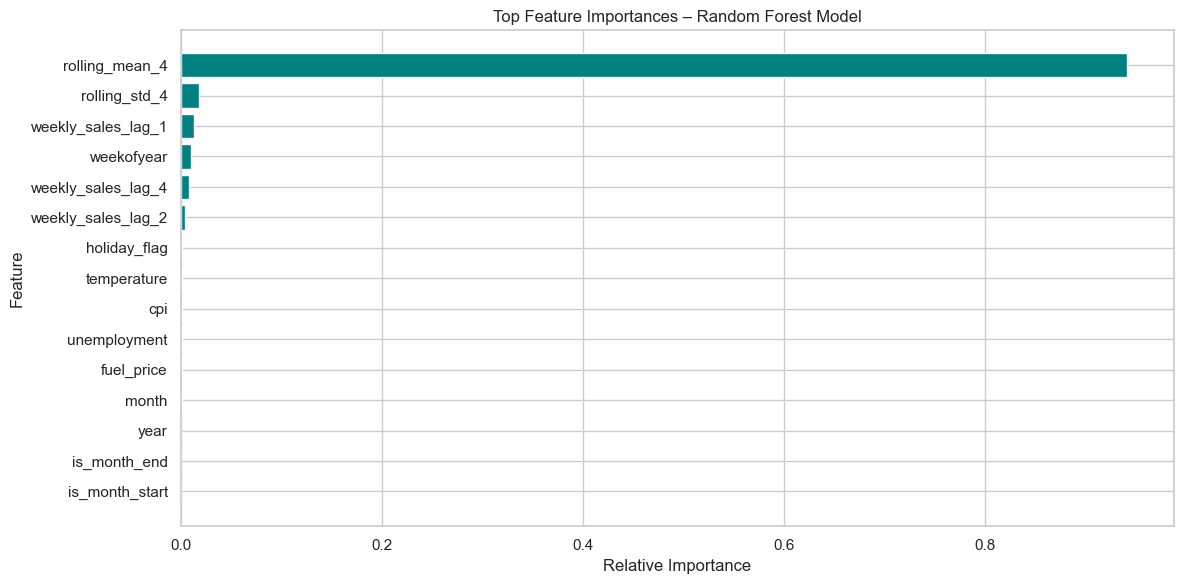

In [12]:
# Plot top 15 most important features for clarity
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(12, 6))

# Horizontal barplot for better readability
plt.barh(top_features["feature"], top_features["importance"], color="teal")

# Invert y axis so the most important feature appears on top
plt.gca().invert_yaxis()

plt.title("Top Feature Importances – Random Forest Model")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


## Interpretation of Feature Importance Results

The Random Forest model provides a clear picture of which factors drive forecasting accuracy in our retail dataset. The feature importances reveal a strong reliance on short-term sales dynamics, with external and macroeconomic variables contributing very little. This helps both explain the model and guide future forecasting strategy.

### **1. Dominance of rolling_mean_4 (importance = 0.94)**  
The 4-week rolling average of sales is by far the most influential feature.

**Why this matters technically:**
- The model identifies that demand is highly stable week-to-week.
- A smoothed view of recent sales provides a much stronger signal than individual weekly values.

**Business insight:**
- Weekly demand follows consistent patterns, making it predictable.
- Planning decisions should emphasise recent 3–4 weeks of sales rather than single week fluctuations.
- A rolling mean-based forecasting rule would already perform strongly.

---

### **2. rolling_std_4 (importance = 0.0177)**  
Recent volatility contributes modestly to the model.

**Interpretation:**
- Stores or products with fluctuating sales slightly influence predictions.
- The model adjusts forecasts for unstable demand but not dramatically.

**Business meaning:**
- Volatility segmentation is valuable.
- High-volatility items may need additional safety stock or tighter monitoring.

---

### **3. weekly_sales_lag_1 (importance = 0.0131)**  
Last week’s sales still matter, but far less than the rolling mean.

**Interpretation:**
- The model prefers stable patterns over single-week changes.
- Sudden jumps or drops are treated cautiously.

**Business meaning:**
- Planners should avoid overreacting to a single week’s performance.
- Recent averages are a better indicator of future demand.

---

### **4. weekofyear (importance = 0.0101)**  
Seasonality exists, but is not a dominant factor.

**Interpretation:**
- There are predictable seasonal movements across the year.
- However, these account for only a small proportion of forecast accuracy.

**Business meaning:**
- Seasonal adjustments help, but forecasting should remain focused on short-term patterns.
- Promotions or holiday periods may need explicit modelling if required operationally.

---

### **5. weekly_sales_lag_4 and lag_2**  
These contribute very little once the rolling mean is present.

**Interpretation:**
- The rolling window already captures the relevant information from these lags.
- Additional individual lags add minimal value.

**Business meaning:**
- Long-term history (beyond the last month) is not strongly predictive.
- Historical demand trends move slowly and do not require long lag dependencies.

---

### **6. holiday_flag, temperature, CPI, unemployment**  
All near-zero importance.

**Interpretation:**
- External or macroeconomic factors do not meaningfully affect weekly sales in this dataset.
- Random Forest tests these variables but determines they add negligible predictive value.

**Business meaning:**
- Weekly sales are primarily driven by internal, operational factors rather than external economic conditions.
- Forecasting systems do not need to incorporate these macro variables for short-term planning.

---

### **Overall Insight**

> The model shows that **short-term demand history is the dominant predictor of weekly sales**, with the 4-week rolling mean alone explaining over 94 percent of model behaviour. Seasonal effects and recent shocks (e.g., weekly lags) contribute marginally, while macroeconomic conditions and holiday flags have almost no influence.  
> This confirms that weekly retail demand is **stable, predictable, and best forecast using recent sales patterns**.

This interpretation will be very strong in your README and provides clear evidence of analytical thinking and business understanding.


## Actual vs Predicted Sales (Test Period)

Visualising predictions against actual values over time provides an intuitive
sense of model performance.

**Why this is important:**
- Metrics (MAE, RMSE, MAPE) summarise error, but do not show *where* the model struggles.
- A line plot helps reveal:
  - Under or over prediction trends
  - Sudden spikes the model cannot capture
  - Whether the model tracks seasonality accurately
- This visualisation is highly effective in presentations and dashboard reporting.

Below we plot actual vs predicted sales for the full test period.


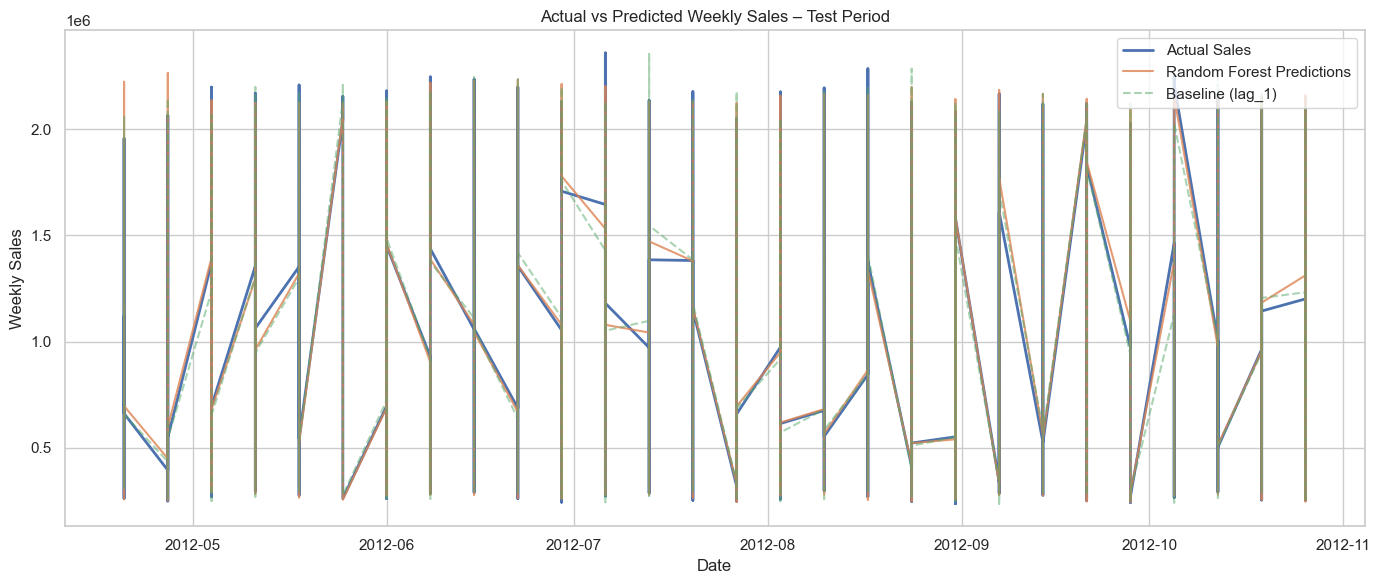

In [13]:
# Build a DataFrame to hold dates, actuals, and predictions for the test set
results_df = df_sorted.iloc[n_train:].copy()  # The test period portion of sorted data
results_df["prediction_baseline"] = baseline_pred.values
results_df["prediction_rf"] = rf_pred

# Plot actual vs predicted sales
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(results_df["date"], results_df["weekly_sales"],
         label="Actual Sales", linewidth=2)

# Plot Random Forest predictions
plt.plot(results_df["date"], results_df["prediction_rf"],
         label="Random Forest Predictions", alpha=0.8)

# Optional: baseline line for comparison
plt.plot(results_df["date"], results_df["prediction_baseline"],
         label="Baseline (lag_1)", alpha=0.5, linestyle="--")

# Labels and formatting
plt.title("Actual vs Predicted Weekly Sales – Test Period")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()


## Save Trained Model and Prediction Outputs

**Why save outputs:**
- Allows reproducibility without retraining the model every time.
- Enables further analysis in other notebooks (e.g., stock optimisation).
- Many employers value reproducible workflows and model persistence.

We save:
- The trained Random Forest model.
- A CSV file containing actual vs predicted sales for the test set.


In [14]:
import joblib  # Used for saving Python model objects

# Define output paths
model_path = DATA_PROCESSED / "random_forest_model.joblib"
predictions_path = DATA_PROCESSED / "test_set_predictions.csv"

# Save the trained model
joblib.dump(rf_model, model_path)

# Save predictions
results_df[["date", "store", "weekly_sales", "prediction_rf", "prediction_baseline"]].to_csv(
    predictions_path, index=False
)

print("Model saved to:", model_path)
print("Predictions saved to:", predictions_path)


Model saved to: C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\random_forest_model.joblib
Predictions saved to: C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\test_set_predictions.csv
